**GenAI-Assisted Neural Network Design**

Imports and configuration

In [4]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


Load the dataset

In [5]:
# Update this path if needed
file_path = "TrafficTwoMonth.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())

Shape: (5952, 9)


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal



Columns: ['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Traffic Situation']


Basic inspection and cleaning

In [6]:
# Standardize column names just in case
df.columns = [col.strip() for col in df.columns]

# Remove exact duplicates if any
df = df.drop_duplicates().reset_index(drop=True)

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Inspect target distribution
print("\nTraffic Situation distribution:")
print(df["Traffic Situation"].value_counts())

display(df.head())

Missing values:
 Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

Traffic Situation distribution:
Traffic Situation
normal    3610
heavy     1137
low        834
high       371
Name: count, dtype: int64


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal


Preprocess time/date features and build model-ready dataframe

In [7]:
# ---- Parse time ----
# Example format in your file: "12:00:00 AM"
df["parsed_time"] = pd.to_datetime(df["Time"], format="%I:%M:%S %p", errors="coerce")

# Drop rows where time cannot be parsed
df = df.dropna(subset=["parsed_time"]).reset_index(drop=True)

# Extract hour and minute
df["hour"] = df["parsed_time"].dt.hour
df["minute"] = df["parsed_time"].dt.minute
df["minute_of_day"] = df["hour"] * 60 + df["minute"]

# ---- Cyclical encoding for time of day ----
df["time_sin"] = np.sin(2 * np.pi * df["minute_of_day"] / 1440)
df["time_cos"] = np.cos(2 * np.pi * df["minute_of_day"] / 1440)

# ---- Encode day of week as cyclical ----
day_order = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
    "Friday": 4, "Saturday": 5, "Sunday": 6
}
df["day_num"] = df["Day of the week"].map(day_order)

# If any unexpected day names exist, handle them
if df["day_num"].isnull().any():
    missing_days = df.loc[df["day_num"].isnull(), "Day of the week"].unique()
    raise ValueError(f"Unexpected day names found: {missing_days}")

df["day_sin"] = np.sin(2 * np.pi * df["day_num"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_num"] / 7)

# ---- Optional cyclical encoding for Date (day of month) ----
# Since the dataset spans multiple days and Date is day-of-month style,
# this can still provide some useful seasonal signal.
df["date_sin"] = np.sin(2 * np.pi * df["Date"] / 31)
df["date_cos"] = np.cos(2 * np.pi * df["Date"] / 31)

# ---- Encode target labels ----
label_encoder = LabelEncoder()
df["target"] = label_encoder.fit_transform(df["Traffic Situation"])

print("Target classes:", list(label_encoder.classes_))

display(df.head())

Target classes: ['heavy', 'high', 'low', 'normal']


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,parsed_time,...,minute,minute_of_day,time_sin,time_cos,day_num,day_sin,day_cos,date_sin,date_cos,target
0,12:00:00 AM,10,Tuesday,13,2,2,24,41,normal,1900-01-01 00:00:00,...,0,0,0.000000,1.000000,1,0.781831,0.62349,0.897805,-0.440394,3
1,12:15:00 AM,10,Tuesday,14,1,1,36,52,normal,1900-01-01 00:15:00,...,15,15,0.065403,0.997859,1,0.781831,0.62349,0.897805,-0.440394,3
2,12:30:00 AM,10,Tuesday,10,2,2,32,46,normal,1900-01-01 00:30:00,...,30,30,0.130526,0.991445,1,0.781831,0.62349,0.897805,-0.440394,3
3,12:45:00 AM,10,Tuesday,10,2,2,36,50,normal,1900-01-01 00:45:00,...,45,45,0.195090,0.980785,1,0.781831,0.62349,0.897805,-0.440394,3
4,1:00:00 AM,10,Tuesday,11,2,1,34,48,normal,1900-01-01 01:00:00,...,0,60,0.258819,0.965926,1,0.781831,0.62349,0.897805,-0.440394,3


Select features and prepare arrays

In [8]:
# Feature columns for the sequence model
feature_cols = [
    "CarCount",
    "BikeCount",
    "BusCount",
    "TruckCount",
    "Total",
    "time_sin",
    "time_cos",
    "day_sin",
    "day_cos",
    "date_sin",
    "date_cos"
]

target_col = "target"

# Keep data in original order because this is time-series
model_df = df[feature_cols + [target_col]].copy()

print("Feature columns:", feature_cols)
print("Number of classes:", len(label_encoder.classes_))
display(model_df.head())

Feature columns: ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'time_sin', 'time_cos', 'day_sin', 'day_cos', 'date_sin', 'date_cos']
Number of classes: 4


,CarCount,BikeCount,BusCount,TruckCount,Total,time_sin,time_cos,day_sin,day_cos,date_sin,date_cos,target
0,13,2,2,24,41,0.000000,1.000000,0.781831,0.62349,0.897805,-0.440394,3
1,14,1,1,36,52,0.065403,0.997859,0.781831,0.62349,0.897805,-0.440394,3
2,10,2,2,32,46,0.130526,0.991445,0.781831,0.62349,0.897805,-0.440394,3
3,10,2,2,36,50,0.195090,0.980785,0.781831,0.62349,0.897805,-0.440394,3
4,11,2,1,34,48,0.258819,0.965926,0.781831,0.62349,0.897805,-0.440394,3


Time-based train/validation/test split

In [9]:
# Time-based split: do not shuffle
n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df   = model_df.iloc[train_end:val_end].copy()
test_df  = model_df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (4166, 12)
Validation shape: (893, 12)
Test shape: (893, 12)


Scale numeric features using training data only

In [10]:
scaler = StandardScaler()

X_train_tab = train_df[feature_cols].values
X_val_tab   = val_df[feature_cols].values
X_test_tab  = test_df[feature_cols].values

y_train_tab = train_df[target_col].values
y_val_tab   = val_df[target_col].values
y_test_tab  = test_df[target_col].values

X_train_scaled = scaler.fit_transform(X_train_tab)
X_val_scaled   = scaler.transform(X_val_tab)
X_test_scaled  = scaler.transform(X_test_tab)

print("Scaled training shape:", X_train_scaled.shape)

Scaled training shape: (4166, 11)


Create sequence windows

In [11]:
def create_sequences(X, y, seq_len=8):
    """
    Create rolling sequences.
    X: 2D array of shape (samples, features)
    y: 1D array of labels
    Returns:
        X_seq: 3D array (samples - seq_len, seq_len, features)
        y_seq: 1D array aligned to the label immediately after each window
    """
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Starting default sequence length
SEQ_LEN = 8

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_tab, seq_len=SEQ_LEN)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_tab, seq_len=SEQ_LEN)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_tab, seq_len=SEQ_LEN)

print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)

X_train_seq shape: (4158, 8, 11)
X_val_seq shape: (885, 8, 11)
X_test_seq shape: (885, 8, 11)


Build the LSTM model

In [12]:
def build_lstm_model(input_shape, num_classes, lstm_units=64, dropout_rate=0.2, learning_rate=1e-3):
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(lstm_units // 2),
        Dropout(dropout_rate),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

num_classes = len(label_encoder.classes_)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model = build_lstm_model(
    input_shape=input_shape,
    num_classes=num_classes,
    lstm_units=64,
    dropout_rate=0.2,
    learning_rate=1e-3
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,060 (129.14 KB)

 Trainable params: 33,060 (129.14 KB)

 Non-trainable params: 0 (0.00 B)

Train the model with early stopping

In [13]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.6335 - loss: 0.9823 - val_accuracy: 0.6395 - val_loss: 0.9370
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7051 - loss: 0.7761 - val_accuracy: 0.6588 - val_loss: 0.8696
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7217 - loss: 0.7214 - val_accuracy: 0.6701 - val_loss: 0.8613
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.7244 - loss: 0.7062 - val_accuracy: 0.6836 - val_loss: 0.8355
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7321 - loss: 0.6849 - val_accuracy: 0.7006 - val_loss: 0.8165
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.7340 - loss: 0.6720 - val_accuracy: 0.7040 - val_loss: 0.8081
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7338 - loss: 0.6615 - val_accuracy: 0.7085 - val_loss: 0.8166
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7335 - loss: 0.6511 - val_acc

Plot training history

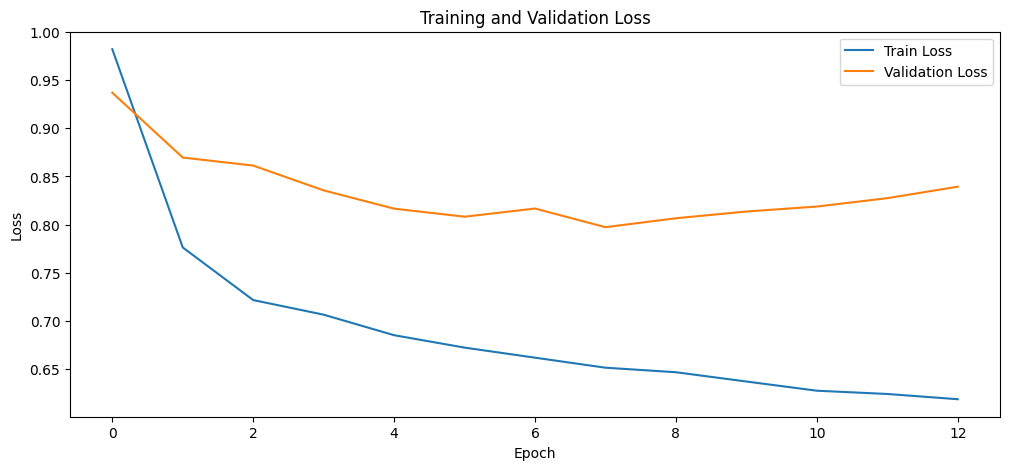

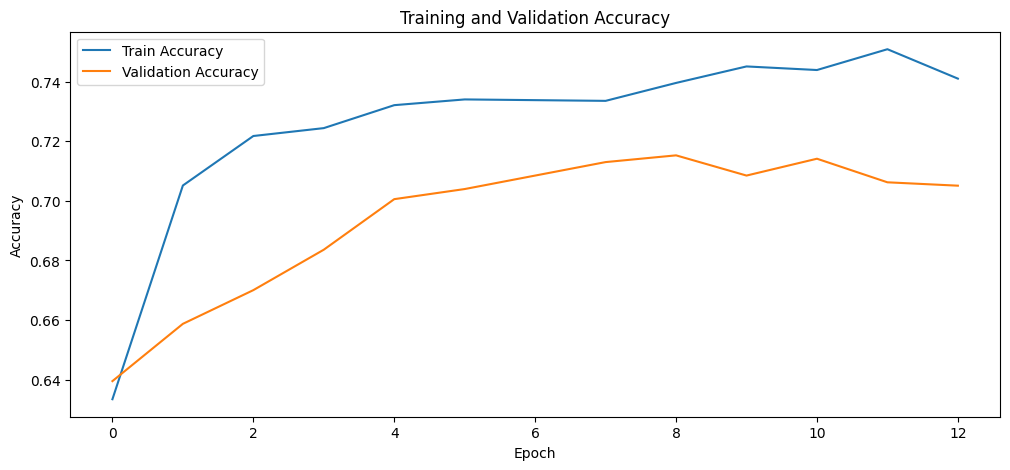

In [14]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Evaluate on the test set

In [15]:
# Predict class probabilities and classes
y_proba = model.predict(X_test_seq)
y_pred = np.argmax(y_proba, axis=1)

accuracy = accuracy_score(y_test_seq, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_seq, y_pred, average="weighted", zero_division=0
)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall   : {recall:.4f}")
print(f"Test F1-score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(
    y_test_seq,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Test Accuracy : 0.7209
Test Precision: 0.6592
Test Recall   : 0.7209
Test F1-score : 0.6720

Classification Report:

              precision    recall  f1-score   support

       heavy       0.77      0.88      0.82       208
        high       0.00      0.00      0.00        61
         low       0.60      0.26      0.36       149
      normal       0.71      0.90      0.79       467

    accuracy                           0.72       885
   macro avg       0.52      0.51      0.49       885
weighted avg       0.66      0.72      0.67       885



Confusion matrix

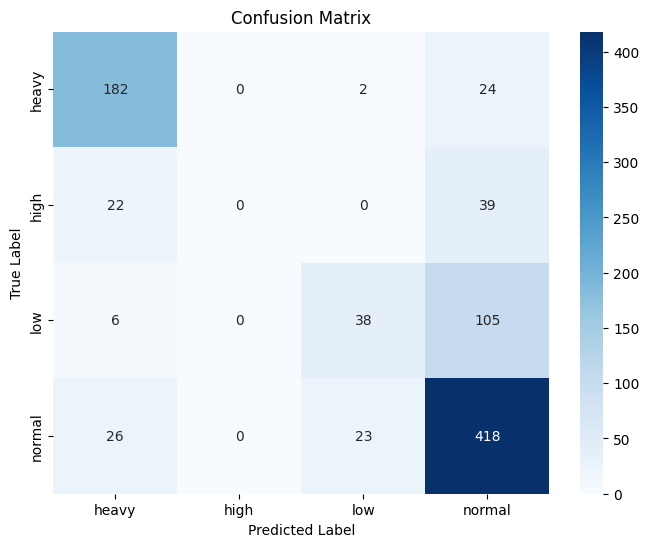

In [16]:
cm = confusion_matrix(y_test_seq, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Example: predict congestion for the next timestep

In [17]:
def predict_next_traffic_state(model, recent_rows_df, scaler, feature_cols, seq_len, label_encoder):
    """
    recent_rows_df should contain the most recent raw rows from the original dataframe,
    at least seq_len rows, and include all columns needed to create engineered features.
    """
    temp_df = recent_rows_df.copy()

    # Recreate engineered features
    temp_df["parsed_time"] = pd.to_datetime(temp_df["Time"], format="%I:%M:%S %p", errors="coerce")
    temp_df["hour"] = temp_df["parsed_time"].dt.hour
    temp_df["minute"] = temp_df["parsed_time"].dt.minute
    temp_df["minute_of_day"] = temp_df["hour"] * 60 + temp_df["minute"]

    temp_df["time_sin"] = np.sin(2 * np.pi * temp_df["minute_of_day"] / 1440)
    temp_df["time_cos"] = np.cos(2 * np.pi * temp_df["minute_of_day"] / 1440)

    temp_df["day_num"] = temp_df["Day of the week"].map({
        "Monday": 0, "Tuesday": 1, "Wednesday": 2, "Thursday": 3,
        "Friday": 4, "Saturday": 5, "Sunday": 6
    })

    temp_df["day_sin"] = np.sin(2 * np.pi * temp_df["day_num"] / 7)
    temp_df["day_cos"] = np.cos(2 * np.pi * temp_df["day_num"] / 7)

    temp_df["date_sin"] = np.sin(2 * np.pi * temp_df["Date"] / 31)
    temp_df["date_cos"] = np.cos(2 * np.pi * temp_df["Date"] / 31)

    X_recent = temp_df[feature_cols].tail(seq_len).values
    X_recent_scaled = scaler.transform(X_recent)
    X_recent_seq = np.expand_dims(X_recent_scaled, axis=0)

    pred_proba = model.predict(X_recent_seq, verbose=0)[0]
    pred_class = np.argmax(pred_proba)
    pred_label = label_encoder.inverse_transform([pred_class])[0]

    return pred_label, pred_proba

# Use the final seq_len rows from the full dataframe as an example
recent_rows = df.tail(SEQ_LEN).copy()

predicted_label, predicted_probabilities = predict_next_traffic_state(
    model=model,
    recent_rows_df=recent_rows,
    scaler=scaler,
    feature_cols=feature_cols,
    seq_len=SEQ_LEN,
    label_encoder=label_encoder
)

print("Predicted next traffic state:", predicted_label)

print("\nClass probabilities:")
for cls, prob in zip(label_encoder.classes_, predicted_probabilities):
    print(f"{cls}: {prob:.4f}")

Predicted next traffic state: normal

Class probabilities:
heavy: 0.0001
high: 0.0011
low: 0.1112
normal: 0.8877
